In [357]:
"""
@authors: Anh Pham, Hoang Tran, Egor Kokko
date: 09.06.2024
"""

'\n@authors: Anh Pham, Hoang Tran, Egor Kokko\ndate: 09.06.2024\n'

In [358]:
import os
import pandas as pd
import psycopg2
import traceback
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [359]:
def get_db_connection():
    return psycopg2.connect(
        database="group_12_2024",
        user="group_12_2024",
        password="73JKSEnw6YJZ",
        host="dbcourse.cs.aalto.fi",
        port="5432"
    )

In [360]:
def execute_query(query):
    connection = None
    try:
        connection = get_db_connection()
        cursor = connection.cursor()
        cursor.execute(query)
        result = cursor.fetchall()
        colnames = [desc[0] for desc in cursor.description]
        df = pd.DataFrame(result, columns=colnames)
        return df
    except (Exception, psycopg2.Error) as error:
        print("Error while executing query", error)
    finally:
        if connection:
            cursor.close()
            connection.close()

In [361]:
def execute_non_query(query):
    connection = None
    try:
        connection = get_db_connection()
        cursor = connection.cursor()
        cursor.execute(query)
        connection.commit()
        print("Executed successfully:", query)
    except (Exception, psycopg2.Error) as error:
        print("Error while executing non-query", error)
    finally:
        if connection:
            cursor.close()
            connection.close() 

In [362]:
def execute_command(command):
    connection = None
    try:
        connection = get_db_connection()
        cursor = connection.cursor()
        cursor.execute(command)
        connection.commit()
    except (Exception, psycopg2.Error) as error:
        print("Error while executing command", error)
    finally:
        if connection:
            cursor.close()
            connection.close()

In [363]:
def drop_tables():
    drop_commands = """
    DROP TABLE IF EXISTS Application CASCADE;
    DROP TABLE IF EXISTS RequestSkill CASCADE;
    DROP TABLE IF EXISTS RequestLocation CASCADE;
    DROP TABLE IF EXISTS VolunteerRequest CASCADE;
    DROP TABLE IF EXISTS VolunteerSkill CASCADE;
    DROP TABLE IF EXISTS VolunteerInterest CASCADE;
    DROP TABLE IF EXISTS VolunteerRange CASCADE;
    DROP TABLE IF EXISTS Volunteer CASCADE;
    DROP TABLE IF EXISTS Skill CASCADE;
    DROP TABLE IF EXISTS Interest CASCADE;
    DROP TABLE IF EXISTS City CASCADE;
    DROP TABLE IF EXISTS Beneficiary CASCADE;
    """
    try:
        commands = drop_commands.split(';')
        for command in commands:
            if command.strip():
                execute_non_query(command)
        print("Tables dropped successfully.")
    except Exception as error:
        print("Error while dropping tables:", error)

drop_tables()

Executed successfully: 
    DROP TABLE IF EXISTS Application CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS RequestSkill CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS RequestLocation CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS VolunteerRequest CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS VolunteerSkill CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS VolunteerInterest CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS VolunteerRange CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS Volunteer CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS Skill CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS Interest CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS City CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS Beneficiary CASCADE
Tables dropped successfully.


In [364]:
def list_tables_and_columns():
    query = """
    SELECT table_name, column_name
    FROM information_schema.columns
    WHERE table_schema = 'public'
    ORDER BY table_name, ordinal_position;
    """
    result_df = execute_query(query)
    print("Tables and Columns:")
    print(result_df)

In [365]:
#Create tables 
def create_tables():
    create_commands = """
    CREATE TABLE City(
        cityID text primary key,
        name text not null,
        geolocation text not null
    );


    CREATE TABLE Beneficiary(
        beneficiaryID int primary key,
        name text not null,
        address text not null,
        cityID text not null,
        foreign key (cityID) REFERENCES City(cityID)
    );

    CREATE TABLE Volunteer(
        volunteerID text primary key,
        birthdate DATE not null,
        cityID text not null,
        name text not null,
        email text not null,
        address text not null,
        readiness int not null,
        foreign key (cityID) REFERENCES City(cityID)
    );

    CREATE TABLE volunteerRequest(
        requestID int primary key,
        title text not null,
        volunteerNumber int not null,
        priority int not null check(priority >= 0 AND priority <= 5),
        startDate DATE not null,
        endDate Date not null,
        registerByDate DATE not null,
        beneficiaryID int not null,
        foreign key (beneficiaryID) REFERENCES Beneficiary(beneficiaryID)
    );

    CREATE TABLE requestSkill(
        requestSkillID int primary key,
        name text not null,
        minimumNeed int not null,
        value int not null check(value >= 0 AND value <= 5),
        requestID int not null,
        foreign key (requestID) REFERENCES volunteerRequest(requestID)
    );

    CREATE TABLE requestLocation(
        requestLocationID int primary key,
        cityID text not null,
        requestID int not null,
        foreign key (cityID) REFERENCES City(cityID),
        foreign key (requestID) REFERENCES volunteerRequest(requestID)
    );

    CREATE TABLE Application(
        applicationID int primary key,
        time DATE not null,
        isValid BOOLEAN not null,
        requestID int not null,
        volunteerID text not null,
        foreign key (requestID) REFERENCES volunteerRequest(requestID),
        foreign key (volunteerID) REFERENCES Volunteer(volunteerID)
    );

    CREATE TABLE volunteerRange(
        volunteerID text not null,
        cityID text not null,
        foreign key (volunteerID) REFERENCES Volunteer(volunteerID),
        foreign key (cityID) REFERENCES City(cityID)
    );

    CREATE TABLE volunteerSkill(
        volunteerSkillID int primary key,
        name text not null,
        volunteerID text not null,
        foreign key (volunteerID) REFERENCES Volunteer(volunteerID)
    );

    CREATE TABLE skill(
        name text primary key,
        description text not null
    );

    CREATE TABLE volunteerInterest(
        volunteerInterestID int primary key,
        name text not null,
        volunteerID text not null,
        foreign key (volunteerID) REFERENCES Volunteer(volunteerID)
    );

    CREATE TABLE Interest(
        name text primary key
    );
    """

    try:
        commands = create_commands.split(';')
        for command in commands:
            if command.strip():
                execute_non_query(command)
        print("Tables created successfully.")
    except Exception as error:
        print("Error while creating tables:", error)

In [366]:
def test():
    query = """
    SELECT *
    FROM volunteerRequest
    """

    result_df = execute_query(query)
    print("The result is:")
    print(result_df)

In [367]:
drop_tables()

Executed successfully: 
    DROP TABLE IF EXISTS Application CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS RequestSkill CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS RequestLocation CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS VolunteerRequest CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS VolunteerSkill CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS VolunteerInterest CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS VolunteerRange CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS Volunteer CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS Skill CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS Interest CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS City CASCADE
Executed successfully: 
    DROP TABLE IF EXISTS Beneficiary CASCADE
Tables dropped successfully.


In [368]:
create_tables()

Executed successfully: 
    CREATE TABLE City(
        cityID text primary key,
        name text not null,
        geolocation text not null
    )
Executed successfully: 


    CREATE TABLE Beneficiary(
        beneficiaryID int primary key,
        name text not null,
        address text not null,
        cityID text not null,
        foreign key (cityID) REFERENCES City(cityID)
    )
Executed successfully: 

    CREATE TABLE Volunteer(
        volunteerID text primary key,
        birthdate DATE not null,
        cityID text not null,
        name text not null,
        email text not null,
        address text not null,
        readiness int not null,
        foreign key (cityID) REFERENCES City(cityID)
    )
Executed successfully: 

    CREATE TABLE volunteerRequest(
        requestID int primary key,
        title text not null,
        volunteerNumber int not null,
        priority int not null check(priority >= 0 AND priority <= 5),
        startDate DATE not null,
        end

In [369]:
list_tables_and_columns()

Tables and Columns:
          table_name       column_name
0        application     applicationid
1        application              time
2        application           isvalid
3        application         requestid
4        application       volunteerid
..               ...               ...
92  volunteerrequest    registerbydate
93  volunteerrequest     beneficiaryid
94    volunteerskill  volunteerskillid
95    volunteerskill              name
96    volunteerskill       volunteerid

[97 rows x 2 columns]


In [370]:
test()

The result is:
Empty DataFrame
Columns: [requestid, title, volunteernumber, priority, startdate, enddate, registerbydate, beneficiaryid]
Index: []


In [371]:
#Insert data
# Load data from all sheets in the Excel file
basepath = os.getcwd()
data_dir = os.path.join(basepath, 'data')
excel_file_path = os.path.join(data_dir, 'data.xlsx')
sheets = pd.read_excel(excel_file_path, sheet_name=None)
print("Sheet names:")
for sheet_name in sheets.keys():
    print(sheet_name)

Sheet names:
city
volunteer
volunteer_range
skill
skill_assignment
interest
interest_assignment
beneficiary
request
request_skill
request_location
volunteer_application


In [372]:
# Function to execute non-query SQL commands (like CREATE, ALTER, INSERT)
def execute_non_query(query, data=None):
    connection = None
    try:
        connection = get_db_connection()
        cursor = connection.cursor()
        if data:
            cursor.executemany(query, data)
        else:
            cursor.execute(query)
        connection.commit()
        print("Executed successfully:", query)
    except (Exception, psycopg2.Error) as error:
        print("Error while executing non-query", error)
        traceback.print_exc()
    finally:
        if connection:
            cursor.close()
            connection.close()

In [373]:
def preview_table(table_name, row_count=5):
    connection = None
    try:
        connection = get_db_connection()
        query = f"SELECT * FROM {table_name} LIMIT {row_count}"
        df = pd.read_sql_query(query, connection)
        print(f"Preview of table {table_name}:")
        display(df.head())
    except (Exception, psycopg2.Error) as error:
        print(f"Error while fetching data from table {table_name}", error)
        traceback.print_exc()
    finally:
        if connection:
            connection.close()

In [374]:
# Function to add auto-incremented primary keys and prepare data for . 
# We added these primary keys since these tables did not have a primary key yet. 
def prepare_data_for_insertion(sheet_name, table_name, df):
    # Rename columns as necessary
    if sheet_name in column_renames:
        df.rename(columns=column_renames[sheet_name], inplace=True)

    # Add primary key columns with auto-increment values
    if table_name in ['volunteerSkill', 'volunteerInterest', 'requestSkill', 'requestLocation']:
        if table_name == 'volunteerSkill':
            df.insert(0, 'volunteerSkillID', range(1, len(df) + 1))
        elif table_name == 'volunteerInterest':
            df.insert(0, 'volunteerInterestID', range(1, len(df) + 1))
        elif table_name == 'requestSkill':
            df.insert(0, 'requestSkillID', range(1, len(df) + 1))
        elif table_name == 'requestLocation':
            df.insert(0, 'requestLocationID', range(1, len(df) + 1))

    # Convert data types to avoid compatibility issues
    df = df.applymap(lambda x: int(x) if isinstance(x, (np.int64, np.int32)) else x)
    df = df.astype(object).where(pd.notnull(df), None)  # Handle NaNs by converting them to None
    return df

In [375]:
# Define a mapping of sheet names to table names (adjust this as needed)
sheet_to_table_mapping = {
    'city': 'city',
    'volunteer': 'volunteer',
    'volunteer_range': 'volunteerRange',
    'skill': 'skill',
    'skill_assignment': 'volunteerSkill',
    'interest': 'interest',
    'interest_assignment': 'volunteerInterest',
    'beneficiary': 'beneficiary',
    'request': 'volunteerRequest',
    'request_skill': 'requestSkill',
    'request_location': 'requestLocation',
    'volunteer_application': 'application'
}

In [376]:
# Rename columns if necessary to match the table schema
column_renames = {
    'city': {'id': 'cityID', 'name': 'name', 'geolocation': 'geolocation'},
    'beneficiary': {'id': 'beneficiaryID', 'name': 'name', 'address': 'address', 'city_id': 'cityID'},
    'volunteer': {'id': 'volunteerID', 'birthdate': 'birthdate', 'city_id': 'cityID', 'name': 'name', 'email': 'email', 'address': 'address', 'travel_readiness': 'readiness'},
    'volunteer_range': {'volunteer_id': 'volunteerID', 'city_id': 'cityID'},
    'skill': {'name': 'name', 'description': 'description'},
    'skill_assignment': {'volunteer_id': 'volunteerID', 'skill_name': 'name'},
    'interest': {'name': 'name'},
    'interest_assignment': {'interest_name': 'name', 'volunteer_id': 'volunteerID'},
    'request': {'id': 'requestID', 'title': 'title', 'beneficiary_id': 'beneficiaryID', 'number_of_volunteers': 'volunteerNumber', 'priority_value': 'priority', 'start_date': 'startDate', 'end_date': 'endDate', 'register_by_date': 'registerByDate'},
    'request_skill': {'request_id': 'requestID', 'skill_name': 'name', 'min_need': 'minimumNeed', 'value': 'value'},
    'request_location': {'request_id': 'requestID', 'city_id': 'cityID'},
    'volunteer_application': {'id': 'applicationID', 'request_id': 'requestID', 'volunteer_id': 'volunteerID', 'modified': 'time', 'is_valid': 'isValid'}
}

In [377]:
# Prepare data for insertion
prepared_data = {}
for sheet_name, df in sheets.items():
    if sheet_name in sheet_to_table_mapping:
        table_name = sheet_to_table_mapping[sheet_name]
        prepared_data[table_name] = prepare_data_for_insertion(sheet_name, table_name, df)
    else:
        print(f"Sheet {sheet_name} does not have a corresponding table mapping.")

C:\Users\eemel\AppData\Local\Temp\ipykernel_2604\247458666.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, (np.int64, np.int32)) else x)
C:\Users\eemel\AppData\Local\Temp\ipykernel_2604\247458666.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, (np.int64, np.int32)) else x)
C:\Users\eemel\AppData\Local\Temp\ipykernel_2604\247458666.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, (np.int64, np.int32)) else x)
C:\Users\eemel\AppData\Local\Temp\ipykernel_2604\247458666.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, (np.int64, np.int32)) else x)
C:\Users\eemel\AppData\Local\Temp\ipykernel_2604\247458666.py:20: FutureWarn

In [378]:
# Insert data into the database
for table_name, df in prepared_data.items():
    columns = ', '.join(df.columns)
    values = ', '.join(['%s'] * len(df.columns))
    insert_query = f"INSERT INTO {table_name} ({columns}) VALUES ({values})"
    data = [tuple(x) for x in df.to_numpy()]
    execute_non_query(insert_query, data)

Executed successfully: INSERT INTO city (name, cityID, geolocation) VALUES (%s, %s, %s)
Executed successfully: INSERT INTO volunteer (volunteerID, birthdate, cityID, name, email, address, readiness) VALUES (%s, %s, %s, %s, %s, %s, %s)
Executed successfully: INSERT INTO volunteerRange (volunteerID, cityID) VALUES (%s, %s)
Executed successfully: INSERT INTO skill (name, description) VALUES (%s, %s)
Executed successfully: INSERT INTO volunteerSkill (volunteerSkillID, volunteerID, name) VALUES (%s, %s, %s)
Executed successfully: INSERT INTO interest (name) VALUES (%s)
Executed successfully: INSERT INTO volunteerInterest (volunteerInterestID, name, volunteerID) VALUES (%s, %s, %s)
Executed successfully: INSERT INTO beneficiary (beneficiaryID, name, address, cityID) VALUES (%s, %s, %s, %s)
Executed successfully: INSERT INTO volunteerRequest (requestID, title, beneficiaryID, volunteerNumber, priority, startDate, endDate, registerByDate) VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
Executed success

In [379]:
# Preview each table one by one
for table_name in sheet_to_table_mapping.values():
    preview_table(table_name)

Preview of table city:


C:\Users\eemel\AppData\Local\Temp\ipykernel_2604\1467596752.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,cityid,name,geolocation
0,704,Rusko,13.4134995/45.792650
1,72,Hailuoto,-79.132557/-40.995129
2,426,Liperi,47.244262/80.880444
3,886,Ulvila,18.6986795/-17.160223
4,834,Tammela,37.935520/12.226293


Preview of table volunteer:


C:\Users\eemel\AppData\Local\Temp\ipykernel_2604\1467596752.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


...

Preview of table requestLocation:


,requestlocationid,cityid,requestid
0,1,704,1
1,2,504,1
2,3,687,1
3,4,426,1
4,5,704,2


Preview of table application:


C:\Users\eemel\AppData\Local\Temp\ipykernel_2604\1467596752.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,applicationid,time,isvalid,requestid,volunteerid
0,1,2024-06-20,True,314,011095-974M
1,2,2023-06-22,True,263,011095-974M
2,3,2024-10-23,True,147,011095-974M
3,4,2024-10-07,True,171,011095-974M
4,5,2023-07-06,False,54,011095-974M


In [380]:
#A. BASIC

In [381]:
# Question 1: Include the starting date and the end date in the title.
def update_request_titles():
    # Update the titles
    update_query = """
    UPDATE volunteerRequest
    SET title = title || ' (' || startdate || ' - ' || endDate || ')'
    WHERE startDate IS NOT NULL AND endDate IS NOT NULL;
    """
    execute_command(update_query)
    print("Request titles updated successfully.")
    
    # Fetch the updated rows
    select_query = """
    SELECT title FROM volunteerRequest
    """
    updated_rows = execute_query(select_query)
    print(updated_rows)
update_request_titles()

Request titles updated successfully.
                                                 title
0        work in team needed (2024-07-25 - 2024-07-28)
1     work with young needed (2022-05-31 - 2022-06-01)
2     guide and teach needed (2024-07-22 - 2024-07-27)
3     guide and teach needed (2024-09-25 - 2024-09-25)
4    work with elderly needed (2021-03-01 - 2021-03...
..                                                 ...
377   work with young needed (2021-12-29 - 2021-12-31)
378  immigrant support needed (2020-07-07 - 2020-07...
379   work with young needed (2020-07-11 - 2020-07-14)
380   work with young needed (2024-06-24 - 2024-06-25)
381  collect donations needed (2024-06-08 - 2024-06...

[382 rows x 1 columns]


In [382]:
# Question 2: Find volunteers whose skill assignments match the requesting skills.
def find_matching_volunteers():
    query = """
    SELECT v.name,
           v.volunteerID,
           rs.requestID,
           COUNT(DISTINCT CASE WHEN rs.name = vs.name THEN rs.name END) AS skill_match
    FROM volunteer v
    JOIN application a ON v.volunteerID = a.volunteerID
    JOIN requestSkill rs ON a.requestID = rs.requestID
    JOIN volunteerSkill vs ON v.volunteerID = vs.volunteerID
    WHERE a.isValid = TRUE
    GROUP BY rs.requestID, v.volunteerID, v.name
    ORDER BY rs.requestID, skill_match DESC;
    """
    result_df = execute_query(query)
    print("Matching Volunteers for each request:")
    print(result_df)

find_matching_volunteers()

Matching Volunteers for each request:
                            name  volunteerid  requestid  skill_match
0                    Mikko Rossi  230283-963X          1            3
1              Henna Hartikainen  011074-9149          1            1
2               Matilda Tuominen  211074-9401          1            1
3           Anniina Saastamoinen  211099-910H          1            1
4                Johannes Jäntti  160903A941P          1            1
...                          ...          ...        ...          ...
2239              Juhani Pesonen  010573-901K        382            7
2240  Olavi Karvinen-Reinikainen  231269-913S        382            5
2241      Outi Luukkonen-Timonen  100396-906V        382            3
2242     Pekka Peltonen-Koivisto  200472-937X        382            1
2243            Karoliina Kallio  210694-902R        382            0

[2244 rows x 4 columns]


In [383]:
# Question 3: Show the missing number of volunteers needed per skill.
def show_missing_volunteers_per_skill():
    query = """
    WITH ValidApplications AS (
        SELECT *
        FROM Application
        WHERE isValid = TRUE
    ),
    VolunteerSkills AS (
        SELECT va.requestID, vs.volunteerID, vs.name AS volunteer_skill
        FROM ValidApplications va
        JOIN volunteerSkill vs ON va.volunteerID = vs.volunteerID
    ),
    RequestSkills AS (
        SELECT rs.requestID, rs.name AS request_skill, rs.minimumNeed
        FROM requestSkill rs
    ),
    MatchingSkills AS (
        SELECT rs.requestID, rs.request_skill, rs.minimumNeed, COUNT(vs.volunteerID) AS volunteer_count
        FROM RequestSkills rs
        LEFT JOIN VolunteerSkills vs ON rs.requestID = vs.requestID AND rs.request_skill = vs.volunteer_skill
        GROUP BY rs.requestID, rs.request_skill, rs.minimumNeed
    ),
    MissingVolunteers AS (
        SELECT requestID, request_skill, minimumNeed, 
               volunteer_count,
               minimumNeed - volunteer_count AS missing_volunteers
        FROM MatchingSkills
    )
    SELECT *
    FROM MissingVolunteers
    WHERE missing_volunteers > 0
    ORDER BY requestID, request_skill;
    """
    result_df = execute_query(query)
    print("Missing Volunteers per Skill:")
    print(result_df)

show_missing_volunteers_per_skill()

Missing Volunteers per Skill:
      requestid              request_skill  minimumneed  volunteer_count  \
0             1  CommunicationAndMarketing            5                3   
1             1               EventHosting            3                2   
2             1          EventOrganization            2                1   
3             2           CookingAndBaking            3                1   
4             2         PublicPerformances            3                2   
...         ...                        ...          ...              ...   
1025        382          DigitalCompetence            3                1   
1026        382               EventHosting            2                1   
1027        382             Organizational            4                2   
1028        382        PhotographyAndVideo            3                1   
1029        382                TrainPeople            3                2   

      missing_volunteers  
0                      2  
1  

In [384]:
# Question 4: Sort requests and the beneficiaries by the highest number of priority and the closest 'register by date'.
def sort_requests_by_priority_and_date():
    query = """
    SELECT vr.requestID, vr.title, vr.priority, vr.registerByDate, b.name AS beneficiary_name
    FROM volunteerRequest vr
    JOIN Beneficiary b ON vr.beneficiaryID = b.beneficiaryID
    ORDER BY vr.priority DESC, vr.registerByDate ASC;
    """
    result_df = execute_query(query)
    print("Sorted Requests and Beneficiaries by Priority and Register Date:")
    print(result_df)

sort_requests_by_priority_and_date()

Sorted Requests and Beneficiaries by Priority and Register Date:
     requestid                                              title  priority  \
0          369   guide and teach needed (2019-12-29 - 2020-01-01)         5   
1          127         food help needed (2020-01-06 - 2020-01-08)         5   
2           92  collect donations needed (2020-02-04 - 2020-02...         5   
3          133  promote wellbeing needed (2020-03-13 - 2020-03...         5   
4          224  collect donations needed (2020-09-20 - 2020-09...         5   
..         ...                                                ...       ...   
377        202  immigrant support needed (2024-11-13 - 2024-11...         0   
378         24         food help needed (2024-11-17 - 2024-11-17)         0   
379        301   guide and teach needed (2024-12-02 - 2024-12-03)         0   
380         81  collect donations needed (2024-11-26 - 2024-11...         0   
381        355    help in crisis needed (2024-12-04 - 2024-12-06) 

In [385]:
# Question 5: List requests within volunteers' range and match at least 2 skills.
def list_requests_within_volunteers_range():
    query = """
    WITH VolunteerSkills AS (
        SELECT vs.volunteerID, vs.name AS skill_name
        FROM volunteerSkill vs
    ),
    RequestSkills AS (
        SELECT rs.requestID, rs.name AS skill_name
        FROM requestSkill rs
    ),
    VolunteerRequestSkills AS (
        SELECT vs.volunteerID, rs.requestID, COUNT(DISTINCT rs.skill_name) AS skill_match_count
        FROM VolunteerSkills vs
        JOIN RequestSkills rs ON vs.skill_name = rs.skill_name
        GROUP BY vs.volunteerID, rs.requestID
    ),
    RequestsInRange AS (
        SELECT vr.volunteerID, rl.requestID
        FROM volunteerRange vr
        JOIN requestLocation rl ON vr.cityID = rl.cityID
    ),
    RequestsWithoutSkills AS (
        SELECT vr.volunteerID, rl.requestID
        FROM volunteerRange vr
        JOIN requestLocation rl ON vr.cityID = rl.cityID
        LEFT JOIN requestSkill rs ON rl.requestID = rs.requestID
        WHERE rs.requestID IS NULL
    ),
    QualifiedRequests AS (
        SELECT rir.volunteerID, rir.requestID
        FROM RequestsInRange rir
        LEFT JOIN VolunteerRequestSkills vrs ON rir.volunteerID = vrs.volunteerID AND rir.requestID = vrs.requestID
        WHERE vrs.skill_match_count >= 2
        UNION
        SELECT * FROM RequestsWithoutSkills
    )
    SELECT q.volunteerID, q.requestID
    FROM QualifiedRequests q
    ORDER BY q.volunteerID, q.requestID;
    """
    result_df = execute_query(query)
    print("Requests within Volunteers' Range:")
    print(result_df)

list_requests_within_volunteers_range()

Requests within Volunteers' Range:
       volunteerid  requestid
0      010469-981A          1
1      010469-981A          2
2      010469-981A          5
3      010469-981A          6
4      010469-981A         10
...            ...        ...
28441  311267-9044        370
28442  311267-9044        372
28443  311267-9044        379
28444  311267-9044        381
28445  311267-9044        382

[28446 rows x 2 columns]


In [386]:
# Question 6
def list_matching_requests_for_volunteers():
    query = r"""
    DROP TABLE IF EXISTS InterestKeyword CASCADE;
    CREATE TABLE InterestKeyword (
        interest_name TEXT PRIMARY KEY,
        keyword TEXT NOT NULL
    );
    
    INSERT INTO InterestKeyword (interest_name, keyword) VALUES
    ('FoodHelp', 'food help'),
    ('GuideAndTeach', 'guide and teach'),
    ('CollectDonations', 'collect donations'),
    ('ImmigrantSupport', 'immigrant support'),
    ('PromoteWellbeing', 'promote wellbeing'),
    ('HelpInCrisis', 'help in crisis'),
    ('WorkWithYoung', 'work with young'),
    ('OrganiseActivities', 'organise activities'),
    ('WorkInMulticulturalEnvironment', 'work in multicultural environment'),
    ('FirstAid', 'first aid'),
    ('WorkWithElderly', 'work with elderly'),
    ('WorkInTeam', 'work in team');
    
    SELECT
        v.volunteerID,
        vr.requestID,
        vr.title,
        vr.registerByDate
    FROM
        Volunteer v
    JOIN
        VolunteerInterest vi ON v.volunteerID = vi.volunteerID
    JOIN
        InterestKeyword ik ON vi.name = ik.interest_name
    JOIN
        volunteerRequest vr ON vr.title ILIKE '%' || ik.keyword || '%'
    WHERE
        vr.registerByDate >= CURRENT_DATE;
    """

    result_df = execute_query(query)
    print("Requests where title matches volunteers' area of interest and are still available to register:")
    print(result_df)

list_matching_requests_for_volunteers()

Requests where title matches volunteers' area of interest and are still available to register:
       volunteerid  requestid  \
0      011095-974M         24   
1      011095-974M         88   
2      011095-974M        220   
3      011095-974M        314   
4      011095-974M          3   
...            ...        ...   
10745  130184-978D        136   
10746  130184-978D        147   
10747  130184-978D        201   
10748  130184-978D        216   
10749  130184-978D        335   

                                                  title registerbydate  
0            food help needed (2024-11-17 - 2024-11-17)     2024-11-12  
1            food help needed (2024-12-12 - 2024-12-12)     2024-11-28  
2            food help needed (2024-08-06 - 2024-08-09)     2024-07-29  
3            food help needed (2024-07-02 - 2024-07-07)     2024-06-26  
4      guide and teach needed (2024-07-22 - 2024-07-27)     2024-07-12  
...                                                 ...            ...

In [387]:
# Question 7
def list_volunteers_outside_location_range():
    query = """
    WITH VolunteersApplied AS (
        SELECT 
            a.requestID, 
            v.volunteerID, 
            v.name, 
            v.email, 
            v.readiness
        FROM Application a
        JOIN Volunteer v ON a.volunteerID = v.volunteerID
        WHERE a.isValid = TRUE
    ),
    RequestLocations AS (
        SELECT 
            rl.requestID, 
            rl.cityID AS request_cityID
        FROM requestLocation rl
    ),
    VolunteerRanges AS (
        SELECT 
            vr.volunteerID, 
            vr.cityID AS volunteer_cityID
        FROM volunteerRange vr
    ),
    VolunteersOutOfRange AS (
        SELECT 
            va.requestID, 
            va.volunteerID, 
            va.name, 
            va.email, 
            va.readiness
        FROM VolunteersApplied va
        LEFT JOIN VolunteerRanges vr ON va.volunteerID = vr.volunteerID
        LEFT JOIN RequestLocations rl ON va.requestID = rl.requestID AND vr.volunteer_cityID = rl.request_cityID
        WHERE rl.requestID IS NULL
    )
    SELECT 
        requestID, 
        volunteerID, 
        name, 
        email, 
        readiness
    FROM VolunteersOutOfRange
    ORDER BY readiness DESC;
    """
    
    result_df = execute_query(query)
    print("Request IDs and volunteers who applied to them but not within the location range of request ordered by readiness to travel:")
    print(result_df)

list_volunteers_outside_location_range()

Request IDs and volunteers who applied to them but not within the location range of request ordered by readiness to travel:
      requestid  volunteerid                       name  \
0           237  111276-945V              Kalervo Rinne   
1           146  111276-945V              Kalervo Rinne   
2           189  111276-945V              Kalervo Rinne   
3           227  111276-945V              Kalervo Rinne   
4           189  111276-945V              Kalervo Rinne   
...         ...          ...                        ...   
3610         76  230168-9007  Maria Hietanen-Parviainen   
3611        148  230168-9007  Maria Hietanen-Parviainen   
3612        148  230168-9007  Maria Hietanen-Parviainen   
3613         77  230168-9007  Maria Hietanen-Parviainen   
3614         55  230168-9007  Maria Hietanen-Parviainen   

                                               email  readiness  
0                 kalervo.rinne@dbcourse.cs.aalto.fi       1439  
1                 kalervo.rinne@dbc

In [388]:
# Question 8
def list_skills_by_priority():
    query = """
    SELECT rs.name, r.priority
    FROM requestSkill rs
    NATURAL JOIN volunteerRequest r
    ORDER BY priority DESC;
    """
    
    result_df = execute_query(query)
    print("Skills based on priority:")
    print(result_df)

list_skills_by_priority()

Skills based on priority:
                           name  priority
0                Organizational         5
1              CookingAndBaking         5
2     CommunicationAndMarketing         5
3                 MeetingPeople         5
4             DigitalCompetence         5
...                         ...       ...
1936         PublicPerformances         0
1937       FinanceAndAccounting         0
1938                  TeamGuide         0
1939       HealthCareOrFirstAid         0
1940               EventHosting         0

[1941 rows x 2 columns]


In [389]:
# Question 9
# This provides an analysis of skill demand by calculating the number of requests each skill is associated with and the average number of volunteers needed 
# for those requests. The results are sorted in descending order of the number of requests and then by the average skill demand. This can be used to see
# what are the most demanded skills
def query_skill_demand():
    query = """
    SELECT
        s.name AS skill_name,
        COUNT(DISTINCT rs.requestID) AS num_requests,
        ROUND(AVG(rs.minimumNeed), 2) AS avg_skill_demand
    FROM skill s
    LEFT JOIN requestSkill rs ON s.name = rs.name
    GROUP BY s.name
    ORDER BY num_requests DESC, avg_skill_demand DESC;
    """
    result_df = execute_query(query)
    print("Skill Demand Analysis:")
    print(result_df)

query_skill_demand()

Skill Demand Analysis:
                   skill_name  num_requests avg_skill_demand
0           EventOrganization           151             3.37
1         PhotographyAndVideo           148             3.61
2        FinanceAndAccounting           148             3.40
3            CookingAndBaking           148             3.30
4              Organizational           143             3.41
5           DigitalCompetence           143             3.38
6                      Rescue           142             3.40
7        HealthCareOrFirstAid           136             3.63
8   CommunicationAndMarketing           135             3.45
9                EventHosting           135             3.44
10                TrainPeople           132             3.52
11              MeetingPeople           128             3.65
12         PublicPerformances           128             3.57
13                  TeamGuide           124             3.77


In [390]:
# Question 10
# This lists the top ten volunteers that have submitted the most requests, which can be used to reward the most active volunteers, in order to motivate them 
# to continue working.
def query_most_active_volunteers():
    query = """
    SELECT
        v.volunteerID AS volunteer_id,
        v.name AS volunteer_name,
        COUNT(a.applicationID) AS number_of_applications
    FROM volunteer v
    JOIN application a ON v.volunteerID = a.volunteerID
    GROUP BY v.volunteerID, v.name
    ORDER BY number_of_applications DESC
    LIMIT 10;
    """
    result_df = execute_query(query)
    print("Most active volunteers:")
    print(result_df)

query_most_active_volunteers()

Most active volunteers:
  volunteer_id           volunteer_name  number_of_applications
0  170254-9461              Elina Kärki                      30
1  210489-9136               Kauko Holm                      29
2  220857-9810           Ville Honkanen                      29
3  011074-9149        Henna Hartikainen                      28
4  100766-9636         Juhani Järvenpää                      28
5  220782-910B        Pauliina Männistö                      28
6  220682-954Y          Helena Salminen                      28
7  231259-9690         Mika Martikainen                      28
8  230881-9561       Annikki Savolainen                      28
9  200472-937X  Pekka Peltonen-Koivisto                      27


In [391]:
# Question 11
# This lists requests that have less applications than needed amount of volunteers. This can be used to identify gaps in volunteer recruitment and 
# to take corrective actions, such as promoting these requests more actively or reassessing the requirements.
def query_unfulfilled_requests():
    query = """
    SELECT
        vr.requestID AS request_id,
        vr.title AS request_name,
        vr.volunteerNumber AS number_needed,
        COUNT(a.applicationID) AS number_of_applications
    FROM volunteerRequest vr
    LEFT JOIN application a ON vr.requestID = a.requestID
    GROUP BY vr.requestID, vr.title, vr.volunteerNumber
    HAVING COUNT(a.applicationID) < vr.volunteerNumber
    ORDER BY vr.requestID;
    """
    result_df = execute_query(query)
    print("Unfulfilled requests:")
    print(result_df)

query_unfulfilled_requests()

Unfulfilled requests:
     request_id                                       request_name  \
0             1      work in team needed (2024-07-25 - 2024-07-28)   
1             2   work with young needed (2022-05-31 - 2022-06-01)   
2             3   guide and teach needed (2024-07-22 - 2024-07-27)   
3             4   guide and teach needed (2024-09-25 - 2024-09-25)   
4             5  work with elderly needed (2021-03-01 - 2021-03...   
..          ...                                                ...   
284         378   work with young needed (2021-12-29 - 2021-12-31)   
285         379  immigrant support needed (2020-07-07 - 2020-07...   
286         380   work with young needed (2020-07-11 - 2020-07-14)   
287         381   work with young needed (2024-06-24 - 2024-06-25)   
288         382  collect donations needed (2024-06-08 - 2024-06...   

     number_needed  number_of_applications  
0               14                       7  
1               25                       6  
2 

In [392]:
# Question 12
# This lists the volunteers who have never applied to any requests, which can clog up the system for no need. These people can either be given more incentive to work
# or be deleted from the system if they do not plan on submitting any requests.
def query_volunteers_without_applications():
    query = """
    SELECT
        v.volunteerID AS volunteer_id,
        v.name AS volunteer_name,
        v.email AS contact_info
    FROM Volunteer v
    LEFT JOIN Application a ON v.volunteerID = a.volunteerID
    WHERE a.applicationID IS NULL
    ORDER BY v.volunteerID;
    """
    result_df = execute_query(query)
    print("Volunteers without applications:")
    print(result_df)

query_volunteers_without_applications()

Volunteers without applications:
  volunteer_id                 volunteer_name  \
0  050677-9718                  Mika Moilanen   
1  250162-950K           Helinä Kukkonen-Mäki   
2  250672-987C                   Aimo Vuorela   
3  280104A9662     Teija Turpeinen-Matikainen   
4  280190-969B  Petteri Heinonen-Jääskeläinen   

                                        contact_info  
0                 mika.moilanen@dbcourse.cs.aalto.fi  
1          helina.kukkonen-maki@dbcourse.cs.aalto.fi  
2                  aimo.vuorela@dbcourse.cs.aalto.fi  
3    teija.turpeinen-matikainen@dbcourse.cs.aalto.fi  
4  petteri.heinonen-jaaskelainen@dbcourse.cs.aalt...  


In [393]:
# Question 12
# This lists the volunteers who have never applied to any requests, which can clog up the system for no need. These people can either be given more incentive to work
# or be deleted from the system if they do not plan on submitting any requests.
def query_volunteers_without_applications():
    query = """
    SELECT
        v.volunteerID AS volunteer_id,
        v.name AS volunteer_name,
        v.email AS contact_info
    FROM Volunteer v
    LEFT JOIN Application a ON v.volunteerID = a.volunteerID
    WHERE a.applicationID IS NULL
    ORDER BY v.volunteerID;
    """
    result_df = execute_query(query)
    print("Volunteers without applications:")
    print(result_df)

query_volunteers_without_applications()

Volunteers without applications:
  volunteer_id                 volunteer_name  \
0  050677-9718                  Mika Moilanen   
1  250162-950K           Helinä Kukkonen-Mäki   
2  250672-987C                   Aimo Vuorela   
3  280104A9662     Teija Turpeinen-Matikainen   
4  280190-969B  Petteri Heinonen-Jääskeläinen   

                                        contact_info  
0                 mika.moilanen@dbcourse.cs.aalto.fi  
1          helina.kukkonen-maki@dbcourse.cs.aalto.fi  
2                  aimo.vuorela@dbcourse.cs.aalto.fi  
3    teija.turpeinen-matikainen@dbcourse.cs.aalto.fi  
4  petteri.heinonen-jaaskelainen@dbcourse.cs.aalt...  


In [394]:
#B. ADVANCED

In [395]:
#B.a. VIEWS

In [396]:
#1.
# View 1. list the average number and age of volunteers that applied, 
# and the average number of volunteers needed for each beneficiary.
def create_beneficiary_stats_view():
    create_view_query = """
    CREATE VIEW BeneficiaryStats AS
    WITH VolunteerAge AS (
        SELECT
            v.volunteerID,
            v.birthdate,
            EXTRACT(YEAR FROM AGE(v.birthdate)) AS age
        FROM Volunteer v
    ),
    RequestVolunteerCounts AS (
        SELECT
            vr.beneficiaryID,
            COUNT(a.applicationID) AS volunteer_count,
            AVG(va.age) AS average_age
        FROM VolunteerRequest vr
        JOIN Application a ON vr.requestID = a.requestID
        JOIN VolunteerAge va ON a.volunteerID = va.volunteerID
        GROUP BY vr.beneficiaryID
    ),
    AverageVolunteersNeeded AS (
        SELECT
            vr.beneficiaryID,
            AVG(vr.volunteerNumber) AS average_volunteers_needed
        FROM VolunteerRequest vr
        GROUP BY vr.beneficiaryID
    )
    SELECT
        b.beneficiaryID,
        b.name AS beneficiary_name,
        COALESCE(rvc.volunteer_count, 0) AS average_volunteers_applied,
        COALESCE(rvc.average_age, 0) AS average_age_of_volunteers,
        COALESCE(avn.average_volunteers_needed, 0) AS average_volunteers_needed
    FROM Beneficiary b
    LEFT JOIN RequestVolunteerCounts rvc ON b.beneficiaryID = rvc.beneficiaryID
    LEFT JOIN AverageVolunteersNeeded avn ON b.beneficiaryID = avn.beneficiaryID;
    """
    
    connection = None
    cursor = None
    try:
        connection = get_db_connection()
        cursor = connection.cursor()

        cursor.execute(create_view_query)
        connection.commit()

        cursor.execute("""
        SELECT 
            beneficiaryID AS beneficiary_id,
            beneficiary_name,
            CAST(ROUND(average_volunteers_applied::NUMERIC, 2) AS FLOAT) AS volunteers_applied,
            CAST(ROUND(average_age_of_volunteers::NUMERIC, 2) AS FLOAT) AS age_volunteers,
            CAST(ROUND(average_volunteers_needed::NUMERIC, 2) AS FLOAT) AS volunteers_needed
        FROM 
            BeneficiaryStats;
        """)
        result = cursor.fetchall()

    except (Exception, psycopg2.Error) as error:
        print("Error while creating/viewing BeneficiaryStats view:", error)
    finally:
        if cursor:
            cursor.close()
        if connection:
            connection.close()

create_beneficiary_stats_view()

In [397]:
#2.
#View 2. Calculates the total number of applications and skills for each volunteer, 
#as well as the average number of skills per application. By calculating the total number 
#of applications and skills for each volunteer, along with the average number of skills per application, 
#active and skilled volunteers can be identified and their level of participation increased.

def create_volunteer_performance_view():
    create_view_query = """
    CREATE VIEW VolunteerPerformance AS
    WITH VolunteerApplicationCounts AS (
        SELECT
            v.volunteerID,
            v.name,
            COUNT(a.applicationID) AS application_count
        FROM Volunteer v
        LEFT JOIN Application a ON v.volunteerID = a.volunteerID
        GROUP BY v.volunteerID
    ),
    VolunteerSkillCounts AS (
        SELECT
            v.volunteerID,
            COUNT(vs.volunteerSkillID) AS skill_count
        FROM Volunteer v
        LEFT JOIN VolunteerSkill vs ON v.volunteerID = vs.volunteerID
        GROUP BY v.volunteerID
    )
    SELECT
        vac.volunteerID,
        vac.name AS volunteer_name,
        COALESCE(vac.application_count, 0) AS application_count,
        COALESCE(vsc.skill_count, 0) AS skill_count,
        ROUND(COALESCE(vsc.skill_count::numeric / NULLIF(vac.application_count, 0), 0), 2) AS avg_skills_per_application
    FROM VolunteerApplicationCounts vac
    LEFT JOIN VolunteerSkillCounts vsc ON vac.volunteerID = vsc.volunteerID;
    """
    
    connection = None
    cursor = None
    try:
        connection = get_db_connection()
        cursor = connection.cursor()
        cursor.execute(create_view_query)
        connection.commit()
        print("VolunteerPerformance view created successfully")
    except (Exception, psycopg2.Error) as error:
        print("Error while creating view:", error)
    finally:
        if cursor:
            cursor.close()
        if connection:
            connection.close()

create_volunteer_performance_view()

VolunteerPerformance view created successfully


In [398]:
#B.b. TRIGGER AND FUNCTIONS

In [399]:
#1. 
#Drop if function and trigger already existed
def drop_existing_trigger_and_function():
    drop_trigger_query = "DROP TRIGGER IF EXISTS check_volunteerID_trigger ON Volunteer;"
    execute_command(drop_trigger_query)

    drop_function_query = """
    DROP FUNCTION IF EXISTS validate_volunteerID CASCADE;
    DROP FUNCTION IF EXISTS calculate_control_character CASCADE;
    """
    execute_command(drop_function_query)
drop_existing_trigger_and_function()

In [400]:
#Create a function defined to create the trigger
def create_calculate_control_character_function():
    create_function_query = """
    CREATE OR REPLACE FUNCTION calculate_control_character(input_string TEXT) RETURNS CHAR AS $$
    DECLARE
        date_part TEXT;
        individual_part TEXT;
        combined_number BIGINT;
        remainder INTEGER;
        control_char CHAR;
    BEGIN
        date_part := SUBSTRING(input_string FROM 1 FOR 6);
        individual_part := SUBSTRING(input_string FROM 8 FOR 3);
        combined_number := CAST(date_part || individual_part AS BIGINT);
        remainder := combined_number % 31;
        control_char := SUBSTRING('0123456789ABCDEFHJKLMNPRSTUVWXY', remainder + 1, 1);
        RETURN control_char;
    END;
    $$ LANGUAGE plpgsql;
    """
    execute_command(create_function_query)
create_calculate_control_character_function()

In [401]:
#Create a function defined to create the trigger
def create_validate_volunteerID_function():
    create_trigger_function_query = """
    CREATE OR REPLACE FUNCTION validate_volunteerID() RETURNS TRIGGER AS $$
    DECLARE
        control_char CHAR;
    BEGIN
        control_char := calculate_control_character(NEW.volunteerID);
        IF control_char <> SUBSTRING(NEW.volunteerID FROM 11 FOR 1) THEN
            RAISE EXCEPTION 'Invalid control character in volunteerID %', NEW.volunteerID;
        END IF;
        IF LENGTH(NEW.volunteerID) <> 11 THEN
            RAISE EXCEPTION 'Invalid length for volunteerID %', NEW.volunteerID;
        END IF;
        IF SUBSTRING(NEW.volunteerID FROM 7 FOR 1) NOT IN ('+', '-', 'A', 'B', 'C', 'D', 'E', 'F', 'X', 'Y', 'W', 'V', 'U') THEN
            RAISE EXCEPTION 'Invalid separator character in volunteerID %', NEW.volunteerID;
        END IF;
        RETURN NEW;
    END;
    $$ LANGUAGE plpgsql;
    """
    execute_command(create_trigger_function_query)
create_validate_volunteerID_function()

In [402]:
#Create the trigger to check volunteer ID
def create_volunteerID_trigger():
    create_trigger_query = """
    CREATE TRIGGER check_volunteerID_trigger
    BEFORE INSERT OR UPDATE ON Volunteer
    FOR EACH ROW
    EXECUTE FUNCTION validate_volunteerID();
    """
    execute_command(create_trigger_query)
create_volunteerID_trigger()

In [403]:
#Insert valid and invalid inputs to test the trigger
def insert_test_volunteer():
    test_valid_insert_query = """
    INSERT INTO Volunteer (volunteerID, birthdate, cityID, name, email, address, readiness) 
    VALUES ('150600A905P', '1990-01-01', '834', 'Eemeli Halminen', 'eemeli.halminen@example.com', 'Ruusulankatu 5', 1203);
    """
    test_invalid_insert_query = """
    INSERT INTO Volunteer (volunteerID, birthdate, cityID, name, email, address, readiness) 
    VALUES ('15060A905X', '1990-01-01', '72', 'Rafal Doe', 'rafal.doe@example.com', 'Otaakari 18', 329);
    """
    execute_command(test_valid_insert_query)
    execute_command(test_invalid_insert_query)

insert_test_volunteer()

Error while executing command invalid input syntax for type bigint: "15060A05X"
CONTEXT:  PL/pgSQL function calculate_control_character(text) line 11 at assignment
PL/pgSQL function validate_volunteerid() line 5 at assignment



In [404]:
#Show the added valid row
def fetch_volunteer(volunteer_id):
    fetch_query = f"SELECT * FROM Volunteer WHERE volunteerID = '{volunteer_id}';"
    return execute_query(fetch_query)
valid_row_df = fetch_volunteer('150600A905P')
print(valid_row_df)

   volunteerid   birthdate cityid             name  \
0  150600A905P  1990-01-01    834  Eemeli Halminen   

                         email         address  readiness  
0  eemeli.halminen@example.com  Ruusulankatu 5       1203  


In [405]:
#Delete the added row 
def delete_volunteer(volunteer_id):
    delete_query = f"DELETE FROM Volunteer WHERE volunteerID = '{volunteer_id}';"
    execute_command(delete_query)
delete_volunteer('150600A905P')

In [406]:
#2.
#Drop if function and trigger already existed
def drop_existing_update_trigger_and_function():
    drop_trigger_and_function_query = """
    DROP TRIGGER IF EXISTS trigger_update_volunteer_number ON requestSkill;
    DROP FUNCTION IF EXISTS update_volunteer_number;
    """
    execute_command(drop_trigger_and_function_query)
drop_existing_update_trigger_and_function()

In [407]:
# Create the function to update volunteer number
def create_update_volunteer_number_function():
    create_function_query = """
    CREATE OR REPLACE FUNCTION update_volunteer_number() RETURNS TRIGGER AS $$
    BEGIN
        UPDATE volunteerRequest
        SET volunteerNumber = (
            SELECT COALESCE(SUM(minimumNeed), 0)
            FROM requestSkill
            WHERE requestID = NEW.requestID
        )
        WHERE requestID = NEW.requestID;
        RETURN NEW;
    END;
    $$ LANGUAGE plpgsql;
    """
    execute_command(create_function_query)
create_update_volunteer_number_function()

In [408]:
# Create the trigger to call the function after update on requestSkill
def create_update_volunteer_number_trigger():
    create_trigger_query = """
    CREATE TRIGGER trigger_update_volunteer_number
    AFTER UPDATE ON requestSkill
    FOR EACH ROW
    EXECUTE FUNCTION update_volunteer_number();
    """
    execute_command(create_trigger_query)
create_update_volunteer_number_trigger()

In [409]:
# Insert a new request skill (for testing)
def insert_request_skill():
    insert_query = """
    INSERT INTO requestSkill (requestSkillID, name, minimumNeed, value, requestID) 
    VALUES (1942, 'SqlAndPython', 3, 2, 1);
    """
    execute_command(insert_query)
insert_request_skill()

In [410]:
# Update the minimum need to trigger the update
def update_minimum_need():
    update_sql = "UPDATE requestSkill SET minimumNeed = 5 WHERE requestSkillID = 1942;" #modify to any minimumNeed and requestSkillID you prefer
    execute_command(update_sql)
update_minimum_need()

In [411]:
# Check the updated volunteer number
def check_volunteer_number():
    update_check_query = "SELECT volunteerNumber FROM volunteerRequest WHERE requestID = 1;"
    return execute_query(update_check_query)
volunteer_update_number = check_volunteer_number()
print(volunteer_update_number)

   volunteernumber
0               17


In [412]:
#Delete the added row
def delete_request_skill():
    delete_query = "DELETE FROM requestSkill WHERE requestSkillID = 1942;"
    execute_command(delete_query)
delete_request_skill()

In [413]:
#B.c. TRANSACTIONS (sql)

In [414]:
#B.d. ANALYSIS

In [415]:
#1.
#Query to get number of volunteers available by city
query_volunteers_available = """
SELECT c.cityID, c.name, COUNT(vr.volunteerID) as volunteers_available
FROM City c
JOIN volunteerRange vr ON c.cityID = vr.cityID
GROUP BY c.cityID, c.name;
"""
df_volunteers_available = execute_query(query_volunteers_available)

In [416]:
#Query to get number of unique volunteers who applied for a request in each city
query_volunteers_applied = """
SELECT c.cityID, c.name, COUNT(DISTINCT a.volunteerID) as volunteers_applied
FROM City c
JOIN requestLocation rl ON c.cityID = rl.cityID
JOIN volunteerRequest vr ON rl.requestID = vr.requestID
JOIN Application a ON vr.requestID = a.requestID
GROUP BY c.cityID, c.name;
"""
df_volunteers_applied = execute_query(query_volunteers_applied)

In [417]:
#Merge dataframes
city_volunteer_data = pd.merge(df_volunteers_available, df_volunteers_applied, on=['cityid', 'name'], how='outer').fillna(0)

In [418]:
#Sort the data to highlight the top and bottom cities
city_volunteer_data_sorted = city_volunteer_data.sort_values(by='volunteers_available', ascending=False)

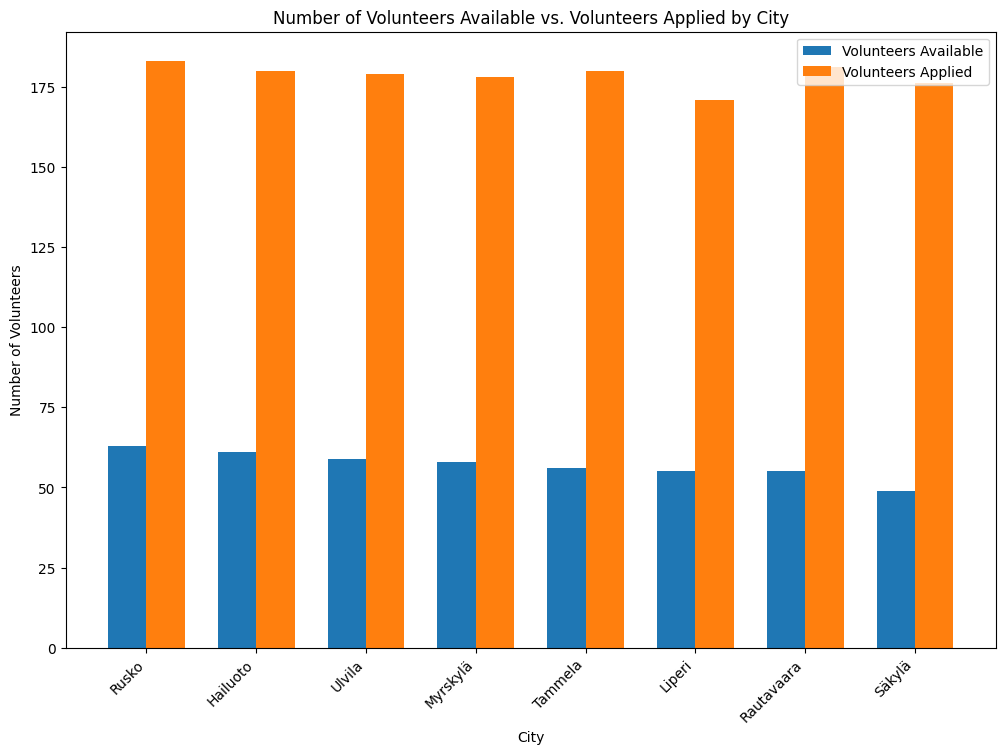

In [419]:
#Plotting the data with side-by-side bars
fig, ax = plt.subplots(figsize=(12, 8))
bar_width = 0.35
index = range(len(city_volunteer_data_sorted))
bar1 = ax.bar(index, city_volunteer_data_sorted['volunteers_available'], bar_width, label='Volunteers Available')
bar2 = ax.bar([i + bar_width for i in index], city_volunteer_data_sorted['volunteers_applied'], bar_width, label='Volunteers Applied')

#Adding titles and labels
ax.set_xlabel('City')
ax.set_ylabel('Number of Volunteers')
ax.set_title('Number of Volunteers Available vs. Volunteers Applied by City')
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(city_volunteer_data_sorted['name'], rotation=45, ha='right')
ax.legend()

In [420]:
#Show the plot
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [421]:
#Top 2 and bottom 2 cities
top_2_cities = city_volunteer_data_sorted.head(2)
bottom_2_cities = city_volunteer_data_sorted.tail(2)

In [422]:
#Show result
top_2_result = "\n".join([f"{row['name']} (City ID {row['cityid']}): {row['volunteers_available']} volunteers available, {row['volunteers_applied']} volunteers applied" for _, row in top_2_cities.iterrows()])
bottom_2_result = "\n".join([f"{row['name']} (City ID {row['cityid']}): {row['volunteers_available']} volunteers available, {row['volunteers_applied']} volunteers applied" for _, row in bottom_2_cities.iterrows()])
result = f"""Top 2 Cities with the Most Volunteers: 
{top_2_result}
Bottom 2 Cities with the Least Volunteers: 
{bottom_2_result}"""
print(result)

Top 2 Cities with the Most Volunteers: 
Rusko (City ID 704): 63 volunteers available, 183 volunteers applied
Hailuoto (City ID 72): 61 volunteers available, 180 volunteers applied
Bottom 2 Cities with the Least Volunteers: 
Rautavaara (City ID 687): 55 volunteers available, 181 volunteers applied
Säkylä (City ID 783): 49 volunteers available, 176 volunteers applied


In [423]:
#2.
# Retrieve data from the database
volunteers_query = "SELECT * FROM Volunteer"
volunteer_skills_query = "SELECT * FROM volunteerSkill"
volunteer_interests_query = "SELECT * FROM volunteerInterest"
volunteer_ranges_query = "SELECT * FROM volunteerRange"
requests_query = "SELECT * FROM volunteerRequest"
request_skills_query = "SELECT * FROM requestSkill"
request_locations_query = "SELECT * FROM requestLocation"
applications_query = "SELECT * FROM Application"

In [424]:
volunteers = execute_query(volunteers_query)
volunteer_skills = execute_query(volunteer_skills_query)
volunteer_interests = execute_query(volunteer_interests_query)
volunteer_ranges = execute_query(volunteer_ranges_query)
requests = execute_query(requests_query)
request_skills = execute_query(request_skills_query)
request_locations = execute_query(request_locations_query)
applications = execute_query(applications_query)

In [425]:
# Maximum travel readiness value for normalization
max_readiness = volunteers['readiness'].max()

In [426]:
# Prepare dictionaries for quick lookups
volunteer_skill_dict = volunteer_skills.groupby('volunteerid')['name'].apply(list).to_dict()
volunteer_interest_dict = volunteer_interests.groupby('volunteerid')['name'].apply(list).to_dict()
volunteer_range_dict = volunteer_ranges.groupby('volunteerid')['cityid'].apply(list).to_dict()
request_skill_dict = request_skills.groupby('requestid')['name'].apply(list).to_dict()
request_location_dict = request_locations.groupby('requestid')['cityid'].apply(list).to_dict()

In [427]:
# Function to calculate the matching score
def calculate_matching_score(volunteer, request_id):
    volunteer_id = volunteer['volunteerid']
    readiness = volunteer['readiness']

    # Skills Match Score
    required_skills = request_skill_dict.get(request_id, [])
    volunteer_skills = volunteer_skill_dict.get(volunteer_id, [])
    skill_score = 40 if set(required_skills).intersection(set(volunteer_skills)) else 0

    # Travel Readiness Score
    travel_readiness_score = (1 - (readiness / max_readiness)) * 20

    # Volunteer Range Score
    request_cities = request_location_dict.get(request_id, [])
    volunteer_cities = volunteer_range_dict.get(volunteer_id, [])
    range_score = 20 if set(request_cities).intersection(set(volunteer_cities)) else 0

    # Interest Alignment Score
    volunteer_interests = volunteer_interest_dict.get(volunteer_id, [])
    matching_interests = set(required_skills).intersection(set(volunteer_interests))
    interest_score = (len(matching_interests) / len(required_skills)) * 20 if required_skills else 0

    # Total Score
    total_score = skill_score + travel_readiness_score + range_score + interest_score
    return total_score

In [428]:
# Calculate scores for each valid application and store the results
application_scores = []
for _, application in applications.iterrows():
    if application['isvalid']:
        volunteer_id = application['volunteerid']
        request_id = application['requestid']
        volunteer = volunteers[volunteers['volunteerid'] == volunteer_id].iloc[0]
        score = calculate_matching_score(volunteer, request_id)
        application_scores.append((request_id, volunteer_id, volunteer['name'], score))

In [429]:
# Convert to DataFrame for easy manipulation
scores_df = pd.DataFrame(application_scores, columns=['requestid', 'volunteerid', 'volunteer_name', 'score'])

In [430]:
# Find top 5 candidates for each request
top_candidates = scores_df.sort_values(by=['requestid', 'score'], ascending=[True, False]).groupby('requestid').head(5)
print(top_candidates)

      requestid  volunteerid              volunteer_name      score
709           1  250681-919H               Tapio Rantala  77.970813
307           1  011074-9149           Henna Hartikainen  73.634468
2121          1  211074-9401            Matilda Tuominen  73.231411
246           1  160903A941P             Johannes Jäntti  65.323141
527           1  211099-910H        Anniina Saastamoinen  62.251564
...         ...          ...                         ...        ...
2269        382  100396-906V      Outi Luukkonen-Timonen  69.214732
1542        382  200472-937X     Pekka Peltonen-Koivisto  63.432940
646         382  010573-901K              Juhani Pesonen  50.173732
2068        382  231269-913S  Olavi Karvinen-Reinikainen  46.059764
1803        382  210694-902R            Karoliina Kallio  20.138985

[1752 rows x 4 columns]


In [431]:
#3.
# Query to get valid applications
applications_query = """
SELECT applicationID, requestID, volunteerID, time, isValid
FROM Application
WHERE isValid = TRUE;
"""
valid_applications_df = execute_query(applications_query)

In [432]:
# Query to get volunteer requests
volunteer_requests_query = """
SELECT requestID, startDate, endDate
FROM volunteerRequest;
"""
volunteer_requests_df = execute_query(volunteer_requests_query)

In [433]:
# Convert date columns to datetime format
valid_applications_df['time'] = pd.to_datetime(valid_applications_df['time'])
volunteer_requests_df['startdate'] = pd.to_datetime(volunteer_requests_df['startdate'])
volunteer_requests_df['enddate'] = pd.to_datetime(volunteer_requests_df['enddate'])

In [434]:
# Extract the month from the 'time' column in the applications dataframe
valid_applications_df['month'] = valid_applications_df['time'].dt.month
print(valid_applications_df['month'])

0        6
1        6
2       10
3       10
4        2
        ..
2429     3
2430     2
2431     9
2432     4
2433     7
Name: month, Length: 2434, dtype: int32


In [435]:
# Extract the month from the 'startDate' column in the volunteer requests dataframe
volunteer_requests_df['month'] = volunteer_requests_df['startdate'].dt.month
print(volunteer_requests_df['month'])

0       5
1       7
2       9
3       3
4      10
       ..
377     7
378     7
379     6
380     6
381     7
Name: month, Length: 382, dtype: int32


In [436]:
# Count the number of valid applications and requests for each month
applications_count_by_month = valid_applications_df.groupby('month').size()
requests_count_by_month = volunteer_requests_df.groupby('month').size()

In [437]:
# Combine the counts into a single dataframe
counts_by_month = pd.DataFrame({
    'applications': applications_count_by_month,
    'requests': requests_count_by_month
}).reset_index().rename(columns={'index': 'month'})
print(counts_by_month)

    month  applications  requests
0       1           152        22
1       2           147        19
2       3           127        28
3       4           183        22
4       5           217        26
5       6           229        41
6       7           307        39
7       8           238        43
8       9           264        43
9      10           202        30
10     11           222        32
11     12           146        37


In [438]:
# Calculate the difference between requests and applications
counts_by_month['difference_requests_application'] = counts_by_month['requests'] - counts_by_month['applications']
counts_by_month['difference_application_request'] = counts_by_month['applications'] - counts_by_month['requests']
print(counts_by_month)

    month  applications  requests  difference_requests_application  \
0       1           152        22                             -130   
1       2           147        19                             -128   
2       3           127        28                              -99   
3       4           183        22                             -161   
4       5           217        26                             -191   
5       6           229        41                             -188   
6       7           307        39                             -268   
7       8           238        43                             -195   
8       9           264        43                             -221   
9      10           202        30                             -172   
10     11           222        32                             -190   
11     12           146        37                             -109   

    difference_application_request  
0                              130  
1              

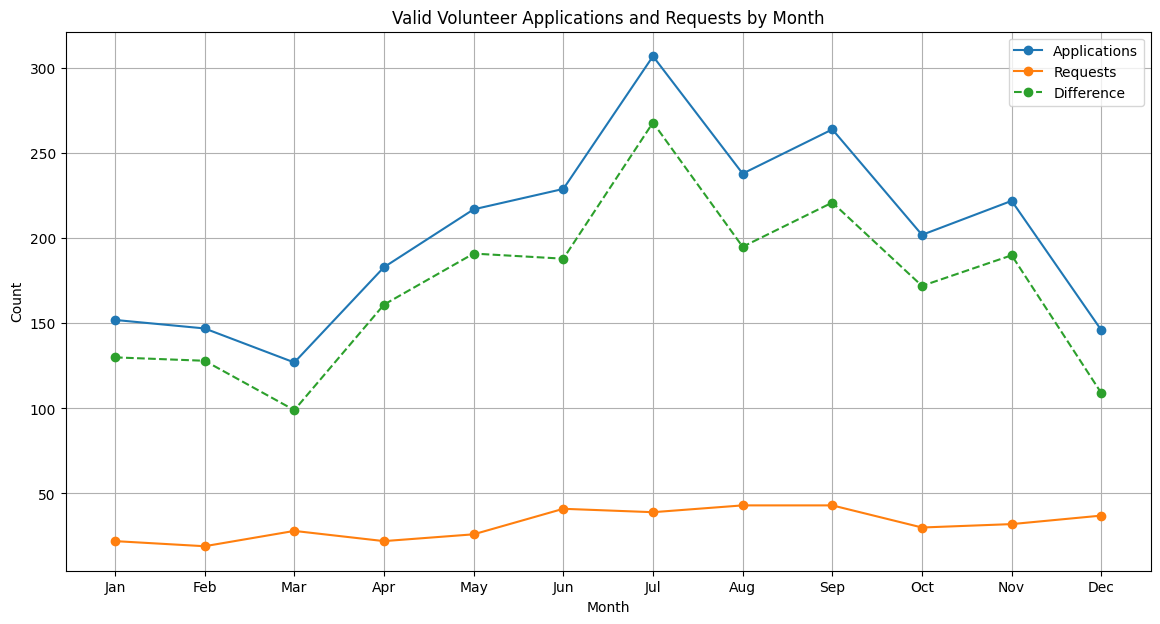

In [439]:
# Plot the data for better visualization
plt.figure(figsize=(14, 7))
# Plot applications and requests
plt.plot(counts_by_month['month'], counts_by_month['applications'], label='Applications', marker='o')
plt.plot(counts_by_month['month'], counts_by_month['requests'], label='Requests', marker='o')
# Plot the differences
plt.plot(counts_by_month['month'], counts_by_month['difference_application_request'], label='Difference', marker='o', linestyle='--')
# Add labels and legend
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Valid Volunteer Applications and Requests by Month')
plt.xticks(range(1, 13),
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True)
# Show the plot
plt.show()

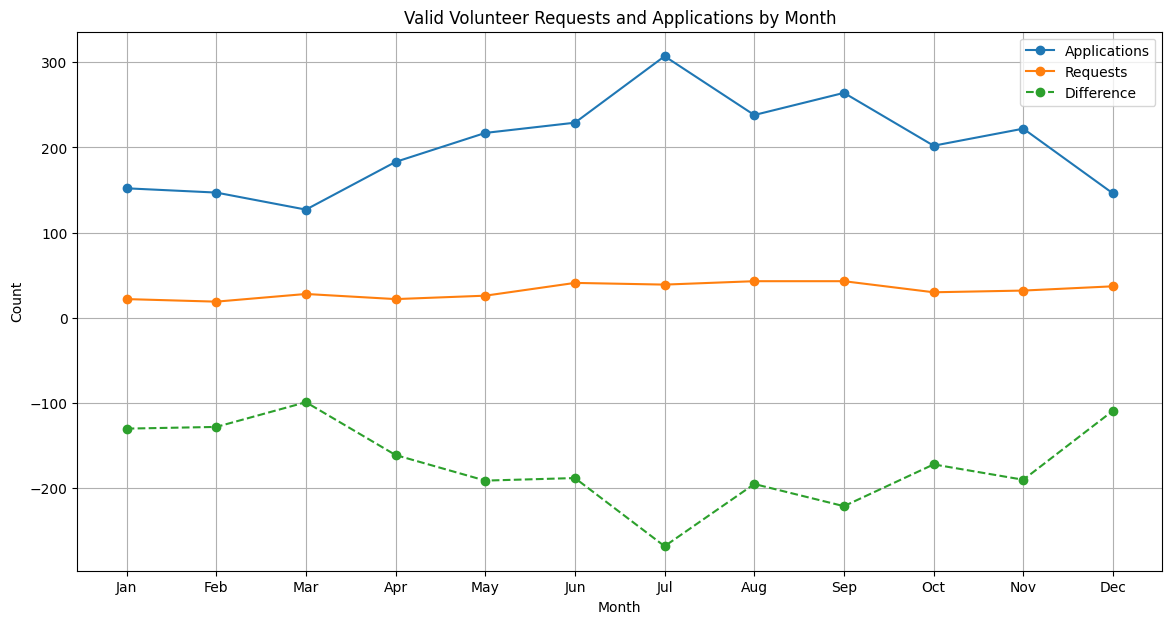

In [440]:
# Plot the data for better visualization
plt.figure(figsize=(14, 7))
# Plot applications and requests
plt.plot(counts_by_month['month'], counts_by_month['applications'], label='Applications', marker='o')
plt.plot(counts_by_month['month'], counts_by_month['requests'], label='Requests', marker='o')
# Plot the differences
plt.plot(counts_by_month['month'], counts_by_month['difference_requests_application'], label='Difference', marker='o', linestyle='--')
# Add labels and legend
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Valid Volunteer Requests and Applications by Month')
plt.xticks(range(1, 13),
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True)
# Show the plot
plt.show()

In [441]:
# Seasonal Trend Analysis
print("Seasonal Trend Analysis")
# Display the counts by month for inspection
print(counts_by_month)
print(' The data shows a seasonal trend in volunteer applications, '
      '\nwith a significant increase during the summer months (June, July, and August). '
      '\nThe peak occurs in July with 307 applications, while the lowest point is in March with 127 applications.'
      '\nThe number of requests does not show as clear a seasonal pattern as the applications. '
      '\nThere is a slight increase in requests during the summer and early autumn months (June to September).'
      '\nThe highest number of requests is in August and September, both with 43 requests, while the lowest is in February with 19 requests.')

Seasonal Trend Analysis
    month  applications  requests  difference_requests_application  \
0       1           152        22                             -130   
1       2           147        19                             -128   
2       3           127        28                              -99   
3       4           183        22                             -161   
4       5           217        26                             -191   
5       6           229        41                             -188   
6       7           307        39                             -268   
7       8           238        43                             -195   
8       9           264        43                             -221   
9      10           202        30                             -172   
10     11           222        32                             -190   
11     12           146        37                             -109   

    difference_application_request  
0                           

In [442]:
# Correlation Analysis
correlation_applications = pearsonr(counts_by_month['month'], counts_by_month['applications'])
correlation_requests = pearsonr(counts_by_month['month'], counts_by_month['requests'])

In [443]:
print("\nCorrelation Analysis")
print(f"Correlation between month and applications: {correlation_applications[0]}, p-value: {correlation_applications[1]}")
print(f"Correlation between month and requests: {correlation_requests[0]}, p-value: {correlation_requests[1]}")


Correlation Analysis
Correlation between month and applications: 0.391713917989075, p-value: 0.2079300569332603
Correlation between month and requests: 0.6563971170557362, p-value: 0.020428590350863387


In [444]:
print('Interpretation: There is a positive but weak correlation between the month and the number of applications. '
      '\nThe p-value is greater than 0.05, indicating that the correlation is not statistically significant. '
      '\nThis suggests that while there is an increase in applications during certain months, '
      '\nthe trend is not strong enough to be deemed significant.')

Interpretation: There is a positive but weak correlation between the month and the number of applications. 
The p-value is greater than 0.05, indicating that the correlation is not statistically significant. 
This suggests that while there is an increase in applications during certain months, 
the trend is not strong enough to be deemed significant.


In [445]:
print('Interpretation: There is a moderate positive correlation between the month and the number of requests. '
      '\nThe p-value is less than 0.05, indicating that the correlation is statistically significant. '
      '\nThis suggests that there is a significant trend of increased requests as the year progresses, '
      '\nespecially during the summer and early autumn months.')

Interpretation: There is a moderate positive correlation between the month and the number of requests. 
The p-value is less than 0.05, indicating that the correlation is statistically significant. 
This suggests that there is a significant trend of increased requests as the year progresses, 
especially during the summer and early autumn months.


In [446]:
# Display the result of months with the most and least valid applications
print("Months with the most and least valid applications:")
most_applications_month = counts_by_month.loc[counts_by_month['applications'].idxmax()]
least_applications_month = counts_by_month.loc[counts_by_month['applications'].idxmin()]
print(f"Most applications: {most_applications_month}")
print(f"Least applications: {least_applications_month}")

Months with the most and least valid applications:
Most applications: month                                7
applications                       307
requests                            39
difference_requests_application   -268
difference_application_request     268
Name: 6, dtype: int64
Least applications: month                                3
applications                       127
requests                            28
difference_requests_application    -99
difference_application_request      99
Name: 2, dtype: int64


In [447]:
# Display the result of months with the most and least valid requests
print("\nMonths with the most and least valid requests:")
most_requests_month = counts_by_month.loc[counts_by_month['requests'].idxmax()]
least_requests_month = counts_by_month.loc[counts_by_month['requests'].idxmin()]
print(f"Most requests: {most_requests_month}")
print(f"Least requests: {least_requests_month}")


Months with the most and least valid requests:
Most requests: month                                8
applications                       238
requests                            43
difference_requests_application   -195
difference_application_request     195
Name: 7, dtype: int64
Least requests: month                                2
applications                       147
requests                            19
difference_requests_application   -128
difference_application_request     128
Name: 1, dtype: int64


In [448]:
#4. This analysis is to understand the distribution and readiness of volunteers across different cities and to 
#investigate if there is any relationship between the number of volunteers in a city and their readiness to travel.

In [449]:
# SQL query to fetch volunteer and city data
query = """
SELECT c.name AS city, COUNT(v.volunteerID) AS volunteer_count, AVG(v.readiness) AS average_readiness
FROM Volunteer v
JOIN City c ON v.cityID = c.cityID
GROUP BY c.name
ORDER BY c.name;
"""
volunteer_data = execute_query(query)

In [450]:
# Convert columns to numeric types
volunteer_data['volunteer_count'] = pd.to_numeric(volunteer_data['volunteer_count'])
volunteer_data['average_readiness'] = pd.to_numeric(volunteer_data['average_readiness'])

In [451]:
# Perform correlation analysis
correlation, _ = pearsonr(volunteer_data['volunteer_count'], volunteer_data['average_readiness'])
print(f'Correlation between number of volunteers and average readiness: {correlation:.2f}')
print(f'The correlation coefficient between the number of volunteers and the average readiness is approximately {correlation:.2f}.'
      f'\nThis indicates a moderate negative correlation, which means that as the number of volunteers in a city increases, '
      f'\nthe average readiness score tends to decrease (which is better since lower readiness scores indicate faster preparation times).')

Correlation between number of volunteers and average readiness: -0.35
The correlation coefficient between the number of volunteers and the average readiness is approximately -0.35.
This indicates a moderate negative correlation, which means that as the number of volunteers in a city increases, 
the average readiness score tends to decrease (which is better since lower readiness scores indicate faster preparation times).


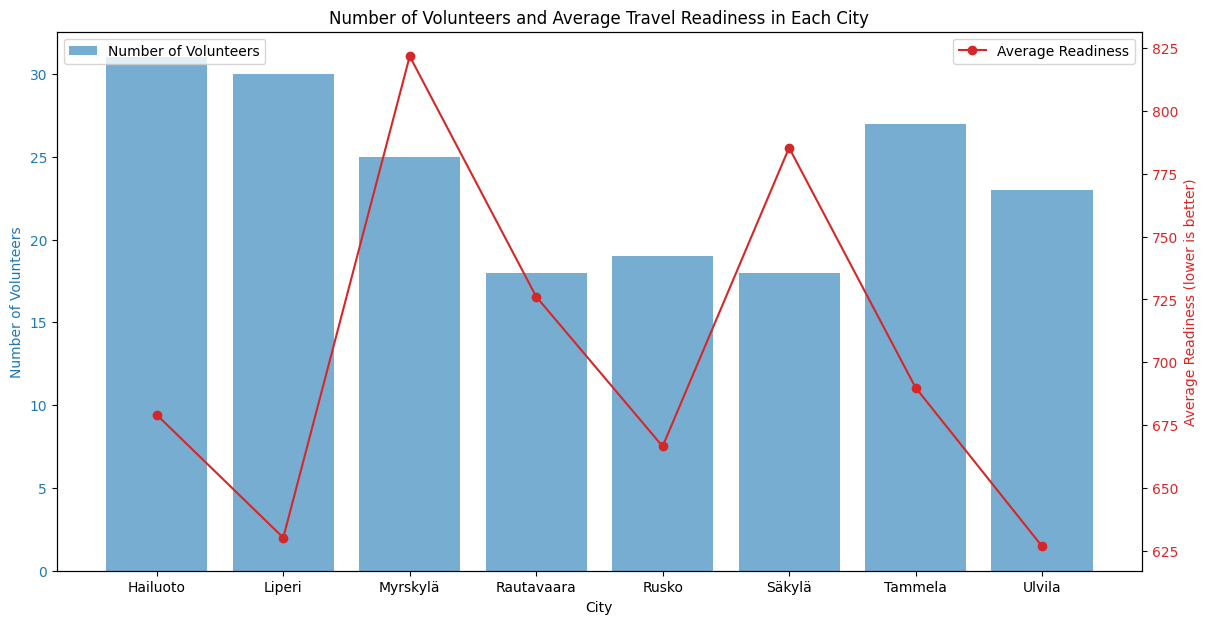

In [452]:
# Plotting the number of volunteers and average readiness in each city on the same graph
fig, ax1 = plt.subplots(figsize=(14, 7))
# Plotting the number of volunteers
color = 'tab:blue'
ax1.set_xlabel('City')
ax1.set_ylabel('Number of Volunteers', color=color)
ax1.bar(volunteer_data['city'], volunteer_data['volunteer_count'], color=color, alpha=0.6, label='Number of Volunteers')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')
# Creating a secondary y-axis to plot the average readiness
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Readiness (lower is better)', color=color)
ax2.plot(volunteer_data['city'], volunteer_data['average_readiness'], color=color, marker='o', linestyle='-', label='Average Readiness')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
# Adding the title and rotating x-axis labels for better readability
plt.title('Number of Volunteers and Average Travel Readiness in Each City')
plt.xticks(rotation=45, ha='right')
# Display the plot
plt.show()